In [ ]:
import zipfile
import pandas as pd

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("resume_data")

df = pd.read_csv("resume_data/gpt_dataset.csv")

print(df.head())
print(df.shape)

             Category                                             Resume
0  Frontend Developer  As a seasoned Frontend Developer, I have a pro...
1   Backend Developer  With a solid background in Backend Development...
2    Python Developer  As a Python Developer, I leverage my expertise...
3      Data Scientist  With a background in Data Science, I possess a...
4  Frontend Developer  Experienced Frontend Developer with a passion ...
(400, 2)


Data visualization provides a graphical understanding of the dataset.

Visualizations used:
• Category Distribution Plot
• Resume Length Distribution
• Word Cloud

Benefits:
• Detect class imbalance.
• Identify dominant skills and keywords.
• Understand data patterns before training.

In [ ]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nUnique Categories:")
print(df['Category'].unique())

print("\nNumber of Classes:")
print(df['Category'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  400 non-null    object
 1   Resume    400 non-null    object
dtypes: object(2)
memory usage: 6.4+ KB
None

Missing Values:
Category    0
Resume      0
dtype: int64

Unique Categories:
['Frontend Developer' 'Backend Developer' 'Python Developer'
 'Data Scientist' 'Full Stack Developer'
 'Mobile App Developer (iOS/Android)' 'Machine Learning Engineer'
 'Cloud Engineer']

Number of Classes:
8


Data visualization provides a graphical understanding of the dataset.

Visualizations used:
• Category Distribution Plot
• Resume Length Distribution
• Word Cloud

Benefits:
• Detect class imbalance.
• Identify dominant skills and keywords.
• Understand data patterns before training.

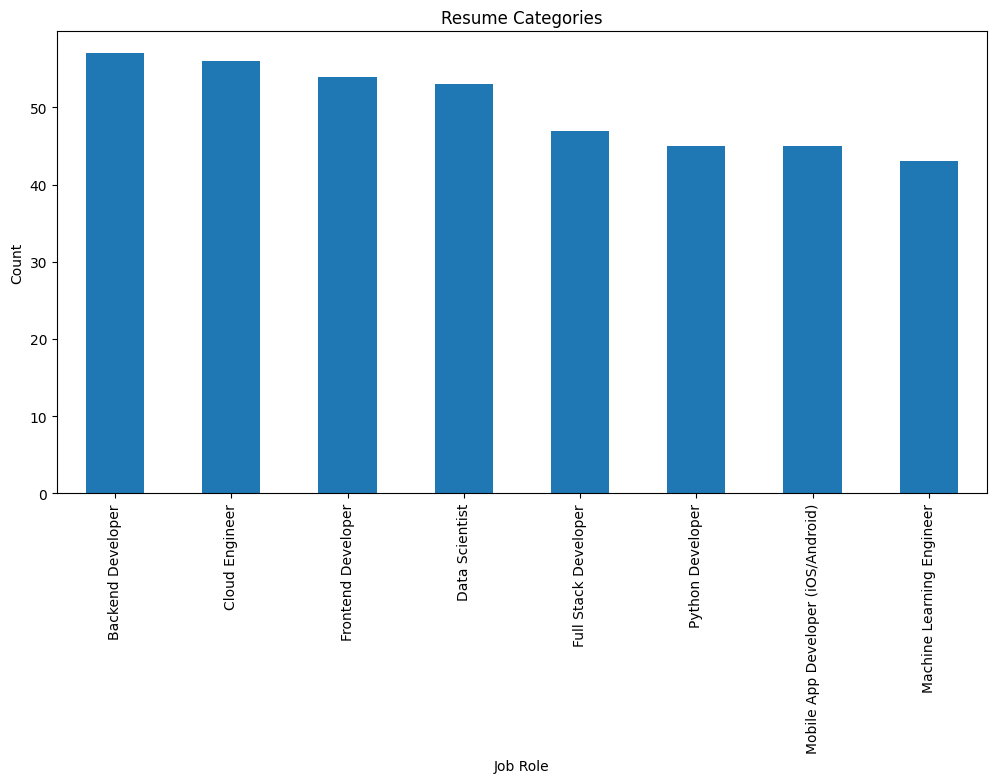

In [ ]:
import matplotlib.pyplot as plt

df['Category'].value_counts().plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Resume Categories")
plt.xlabel("Job Role")
plt.ylabel("Count")
plt.show()

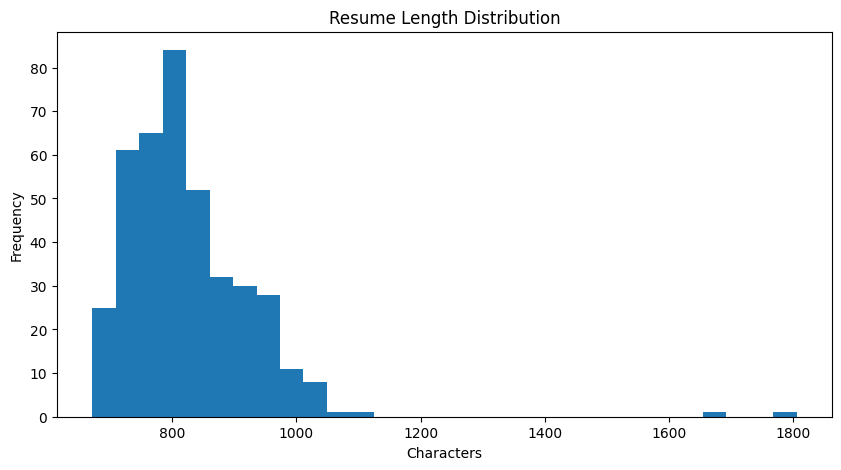

In [ ]:
df['Resume_Length'] = df['Resume'].apply(len)

plt.figure(figsize=(10,5))
plt.hist(df['Resume_Length'], bins=30)

plt.title("Resume Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

Raw resume text contains unnecessary information such as punctuation, special characters, URLs, and inconsistent formatting.

Text preprocessing is performed to:
• Convert text to lowercase.
• Remove special characters.
• Remove extra spaces.
• Standardize the text format.

This improves feature extraction and model performance.

In [ ]:
import re

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text

df['Resume'] = df['Resume'].apply(clean_text)

Machine learning algorithms cannot process categorical labels directly.

Label Encoding converts job categories into numerical values.

Example:
Data Analyst → 0
Software Developer → 1
Machine Learning Engineer → 2

This allows the classification model to learn from category labels.

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Category'] = encoder.fit_transform(
    df['Category']
)

print(encoder.classes_)

['Backend Developer' 'Cloud Engineer' 'Data Scientist'
 'Frontend Developer' 'Full Stack Developer' 'Machine Learning Engineer'
 'Mobile App Developer (iOS/Android)' 'Python Developer']


TF-IDF (Term Frequency-Inverse Document Frequency) converts textual resume data into numerical feature vectors.

Reasons for choosing TF-IDF:
• Captures important keywords.
• Reduces the impact of common words.
• Works effectively for text classification tasks.
• Produces sparse and efficient feature representations.

TF-IDF helps transform resumes into a format understandable by machine learning models.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = tfidf.fit_transform(df['Resume'])

y = df['Category']

The dataset is divided into training and testing sets to evaluate model performance on unseen data.

Training Set:
Used to train the model.

Testing Set:
Used to evaluate the model's generalization ability.

An 80:20 split is used to maintain sufficient data for both training and evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Logistic Regression is used as a baseline classification model.

Reasons:
• Simple and efficient.
• Fast training time.
• Performs well on linearly separable text data.
• Provides a benchmark for comparison with other models.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Reasons:
• Handles high-dimensional data.
• Reduces overfitting.
• Captures complex relationships.
• Provides feature importance information.

It serves as a robust traditional machine learning classifier.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

Support Vector Machine (SVM) is chosen as the primary classification model.

Reasons:
• Highly effective for text classification.
• Performs exceptionally well with TF-IDF features.
• Handles high-dimensional sparse data efficiently.
• Maximizes class separation using optimal hyperplanes.
• Generally achieves higher accuracy than Logistic Regression and Random Forest for NLP tasks.

Due to its strong performance on textual data, SVM is selected as the final model for resume classification.

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train,y_train)

svm_pred = svm.predict(X_test)

Model evaluation is performed to assess the effectiveness of the trained classifier.

Metrics used:
• Accuracy
• Precision
• Recall
• F1-Score
• Confusion Matrix

These metrics provide a comprehensive understanding of model performance and classification quality.

In [ ]:
from sklearn.metrics import accuracy_score

print("LR Accuracy:",
      accuracy_score(y_test,lr_pred))

print("RF Accuracy:",
      accuracy_score(y_test,rf_pred))

print("SVM Accuracy:",
      accuracy_score(y_test,svm_pred))

LR Accuracy: 1.0
RF Accuracy: 1.0
SVM Accuracy: 1.0


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        svm_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00         9
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         9
           7       1.00      1.00      1.00         9

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



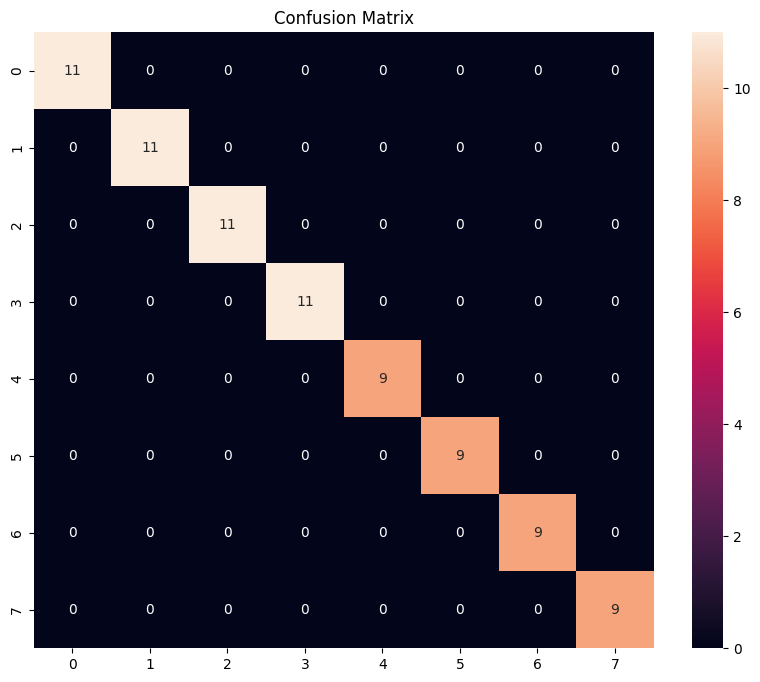

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

In [ ]:
import pickle

pickle.dump(
    svm,
    open("resume_model.pkl","wb")
)

pickle.dump(
    tfidf,
    open("tfidf.pkl","wb")
)

pickle.dump(
    encoder,
    open("encoder.pkl","wb")
)

In [ ]:
!apt-get install tesseract-ocr -y
!pip install pytesseract pdf2image

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.5 MB/s eta 0:00:00


In [ ]:
from google.colab import files

uploaded = files.upload()

file_path = list(uploaded.keys())[0]

print("Uploaded File:", file_path)

Saving AjayKumar.docx to AjayKumar.docx
Uploaded File: AjayKumar.docx


OCR (Optical Character Recognition) is used to extract text from image-based resumes and scanned PDF documents.

Reasons:
• Supports image resume uploads.
• Enables processing of scanned documents.
• Converts visual text into machine-readable format.
• Expands the usability of the resume classification system.

Tesseract OCR is used due to its open-source nature and high accuracy.

In [ ]:
from pdf2image import convert_from_path
import pytesseract

def extract_text_pdf(pdf_path):

    pages = convert_from_path(pdf_path)

    text = ""

    for page in pages:
        text += pytesseract.image_to_string(page)

    return text

# Resume Classification Using Uploaded Files

This section enables users to upload resumes in PDF, DOCX, or image formats. The system automatically detects the file type and extracts textual information using OCR or document processing techniques.

The extracted text is preprocessed and transformed using the previously trained TF-IDF vectorizer. The trained SVM classifier then predicts the most suitable job role, and the encoded prediction is converted back to its original category label.

Technologies Used:
• Tesseract OCR – Image text extraction
• Python-docx – DOCX text extraction
• TF-IDF – Feature extraction
• SVM – Resume classification

In [ ]:
import os
from PIL import Image
import pytesseract
import docx

def extract_text_image(image_path):
    try:
        img = Image.open(image_path)
        text = pytesseract.image_to_string(img)
        return text
    except Exception as e:
        print(f"Error extracting text from image file {image_path}: {e}")
        return ""

def extract_text_docx(docx_path):
    try:
        document = docx.Document(docx_path)
        fullText = []
        for para in document.paragraphs:
            fullText.append(para.text)
        return '\n'.join(fullText)
    except Exception as e:
        print(f"Error extracting text from DOCX file {docx_path}: {e}")
        return ""

def predict_resume(text):
    # Assumes clean_text, svm, tfidf, encoder are available from previously executed cells.
    cleaned_text = clean_text(text)
    vectorized_text = tfidf.transform([cleaned_text])
    prediction_encoded = svm.predict(vectorized_text)
    prediction_label = encoder.inverse_transform(prediction_encoded)
    return prediction_label[0]

extension = os.path.splitext(file_path)[1].lower()
resume_text = ""

if extension == ".pdf":
    resume_text = extract_text_pdf(file_path)
elif extension == ".docx":
    resume_text = extract_text_docx(file_path)
elif extension in [".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".gif"]:
    resume_text = extract_text_image(file_path)
else:
    print(f"Unsupported file type: {extension}. Please upload a PDF, DOCX, or an image file.")
    resume_text = ""

if resume_text:
    prediction = predict_resume(resume_text)
    print("Predicted Role:", prediction)
else:
    print("Could not extract text from the file for prediction.")

Predicted Role: Data Scientist
